In [2]:
import gc
gc.collect()

0

In [3]:
import sys

import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# EEGNet-specific imports
from EEGModels import EEGNet
from tensorflow.keras import utils as np_utils
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import backend as K

import tensorflow.keras as keras
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K
import tensorflow.keras.models as models
import tensorflow.compat.v1 as tf
import numpy as np
from tslearn.metrics import soft_dtw
import os
import mne
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Permute, Dropout, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import SeparableConv2D, DepthwiseConv2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import SpatialDropout2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.layers import Input, Flatten
from tensorflow.keras.constraints import max_norm
from tensorflow.keras import backend as K
from scipy.signal import butter, filtfilt
from sklearn.model_selection import KFold
from scipy import io, signal
import math

import json

def extract_accuracies_from_file(file_path):
    # Open and load the JSON file
    with open(file_path, 'r') as file:
        json_data = json.load(file)
    
    # Extract the accuracies into a list
    accuracies = [data[0].get("accuracy", None) for data in json_data.values()]
    return accuracies
    
def calculate_itr(classification_acc, num_targets, target_selection_time_seconds):          
    p = classification_acc
    logp = np.log2(p)
    ip = 1.0 - p

    a = np.log2(num_targets)
    b = p * logp
    c = ip * np.log2( ip/(num_targets-1) )
    result = a + b + c
    return result * (60 / target_selection_time_seconds)


In [4]:
# type_lowcut_segments

cca_8_100 = np.array(extract_accuracies_from_file("results/cca_results_9chan_8_90_0.4s.json")) / 100
cca_8_150 = np.array(extract_accuracies_from_file("results/cca_results_9chan_8_90_0.6s.json")) / 100
cca_8_200 = np.array(extract_accuracies_from_file("results/cca_results_9chan_8_90_0.8s.json")) / 100
cca_8_250 = np.array(extract_accuracies_from_file("results/cca_results_9chan_8_90_1.0s.json")) / 100

cca_16_100 = np.array(extract_accuracies_from_file("results/cca_results_9chan_16_90_0.4s.json")) / 100
cca_16_150 = np.array(extract_accuracies_from_file("results/cca_results_9chan_16_90_0.6s.json")) / 100
cca_16_200 = np.array(extract_accuracies_from_file("results/cca_results_9chan_16_90_0.8s.json")) / 100
cca_16_250 = np.array(extract_accuracies_from_file("results/cca_results_9chan_16_90_1.0s.json")) / 100

cca_24_100 = np.array(extract_accuracies_from_file("results/cca_results_9chan_24_90_0.4s.json")) / 100
cca_24_150 = np.array(extract_accuracies_from_file("results/cca_results_9chan_24_90_0.6s.json")) / 100
cca_24_200 = np.array(extract_accuracies_from_file("results/cca_results_9chan_24_90_0.8s.json")) / 100
cca_24_250 = np.array(extract_accuracies_from_file("results/cca_results_9chan_24_90_1.0s.json")) / 100

eeg_8_100 = extract_accuracies_from_file("results/eeg_results2_9chans_8_90_100.json")
eeg_8_150 = extract_accuracies_from_file("results/eeg_results2_9chans_8_90_150.json")
eeg_8_200 = extract_accuracies_from_file("results/eeg_results2_9chans_8_90_200.json")
eeg_8_250 = extract_accuracies_from_file("results/eeg_results2_9chans_8_90_250.json")

eeg_16_100 = extract_accuracies_from_file("results/eeg_results2_9chans_16_90_100.json")
eeg_16_150 = extract_accuracies_from_file("results/eeg_results2_9chans_16_90_150.json")
eeg_16_200 = extract_accuracies_from_file("results/eeg_results2_9chans_16_90_200.json")
eeg_16_250 = extract_accuracies_from_file("results/eeg_results2_9chans_16_90_250.json")

eeg_24_100 = extract_accuracies_from_file("results/eeg_results2_9chans_24_90_100.json")
eeg_24_150 = extract_accuracies_from_file("results/eeg_results2_9chans_24_90_150.json")
eeg_24_200 = extract_accuracies_from_file("results/eeg_results2_9chans_24_90_200.json")
eeg_24_250 = extract_accuracies_from_file("results/eeg_results2_9chans_24_90_250.json")

eeg_fusion3_100 = extract_accuracies_from_file("results/eeg_fusion3_results_9chans_90_100.json")
eeg_fusion3_150 = extract_accuracies_from_file("results/eeg_fusion3_results_9chans_90_150.json")
eeg_fusion3_200 = extract_accuracies_from_file("results/eeg_fusion3_results_9chans_90_200.json")
eeg_fusion3_250 = extract_accuracies_from_file("results/eeg_fusion3_results_9chans_90_250.json")

accuracies1 = [
    cca_8_100, cca_8_150, cca_8_200, cca_8_250,  # CCA model
    eeg_8_100, eeg_8_150, eeg_8_200, eeg_8_250,  # EEG model
    eeg_fusion3_100, eeg_fusion3_150, eeg_fusion3_200, eeg_fusion3_250  # EEG FUSION model
]

#print(calculate_itr(np.mean(eeg_fusion3_100), 10, 0.4))
#print(calculate_itr(np.mean(eeg_fusion3_150), 10, 0.6))
#print(calculate_itr(np.mean(eeg_fusion3_200), 10, 0.8))
#print(calculate_itr(np.mean(eeg_fusion3_250), 10, 1.0))

itr_time = [0.4,0.6,0.8,1.0] * 3
itr_time2 = [0.4, 0.6, 0.8, 1.0]

mean_accuracies1 = [np.mean(acc) for acc in accuracies1]
std_devs1 = [np.std(acc) for acc in accuracies1]

accuracies2 = [
    cca_16_100, cca_16_150, cca_16_200, cca_16_250,  # CCA model
    eeg_16_100, eeg_16_150, eeg_16_200, eeg_16_250,  # EEG model
    eeg_fusion3_100, eeg_fusion3_150, eeg_fusion3_200, eeg_fusion3_250  # EEG FUSION model
]

mean_accuracies2 = [np.mean(acc) for acc in accuracies2]
std_devs2 = [np.std(acc) for acc in accuracies2]

accuracies3 = [
    cca_24_100, cca_24_150, cca_24_200, cca_24_250,  # CCA model
    eeg_24_100, eeg_24_150, eeg_24_200, eeg_24_250,  # EEG model
    eeg_fusion3_100, eeg_fusion3_150, eeg_fusion3_200, eeg_fusion3_250  # EEG FUSION model
]

mean_accuracies3 = [np.mean(acc) for acc in accuracies3]
std_devs3 = [np.std(acc) for acc in accuracies3]

itr1 = [calculate_itr(mean_accuracies1[i], 10, itr_time[i]) for i in range(len(mean_accuracies1))]
itr1_std = []
for i in range(len(accuracies1)):
    itrs = []
    for acc in accuracies1[i]:
        itrs.append(calculate_itr(acc, 10, itr_time[i]))
    itr1_std.append(np.std(itrs))

itr2 = [calculate_itr(mean_accuracies2[i], 10, itr_time[i]) for i in range(len(mean_accuracies2))]
itr2_std = []
for i in range(len(accuracies2)):
    itrs = []
    for acc in accuracies1[2]:
        itrs.append(calculate_itr(acc, 10, itr_time[i]))
    itr2_std.append(np.std(itrs))

itr3 = [calculate_itr(mean_accuracies3[i], 10, itr_time[i]) for i in range(len(mean_accuracies3))]
itr3_std = []
for i in range(len(accuracies1)):
    itrs = []
    for acc in accuracies1[i]:
        itrs.append(calculate_itr(acc, 10, itr_time[i]))
    itr1_std.append(np.std(itrs))


C:\Users\qianqian\AppData\Local\Temp\ipykernel_4648\4275466635.py:62: RuntimeWarning: divide by zero encountered in log2
  c = ip * np.log2( ip/(num_targets-1) )
C:\Users\qianqian\AppData\Local\Temp\ipykernel_4648\4275466635.py:62: RuntimeWarning: invalid value encountered in scalar multiply
  c = ip * np.log2( ip/(num_targets-1) )


# Segment length vs accuracy

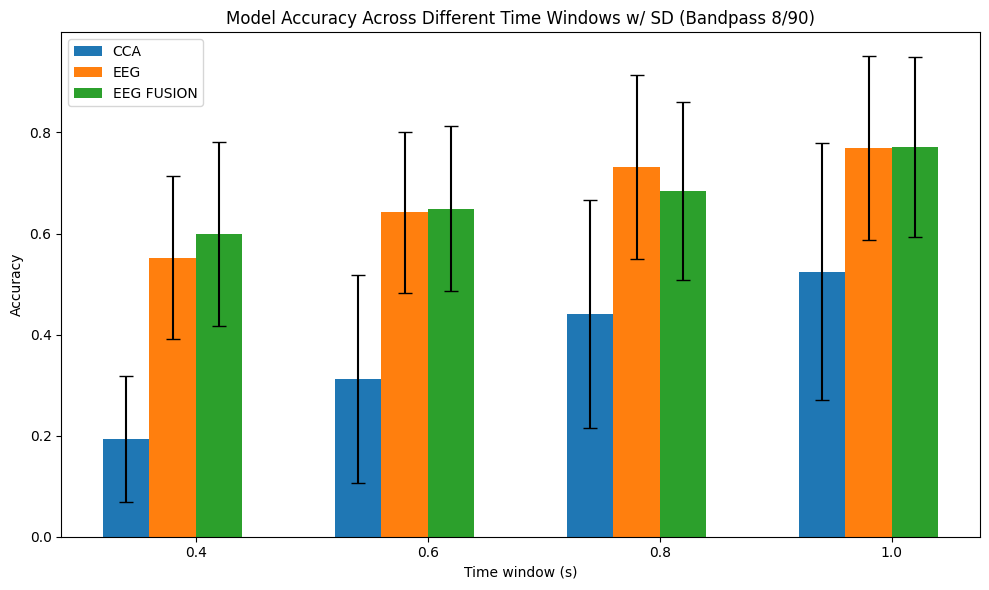

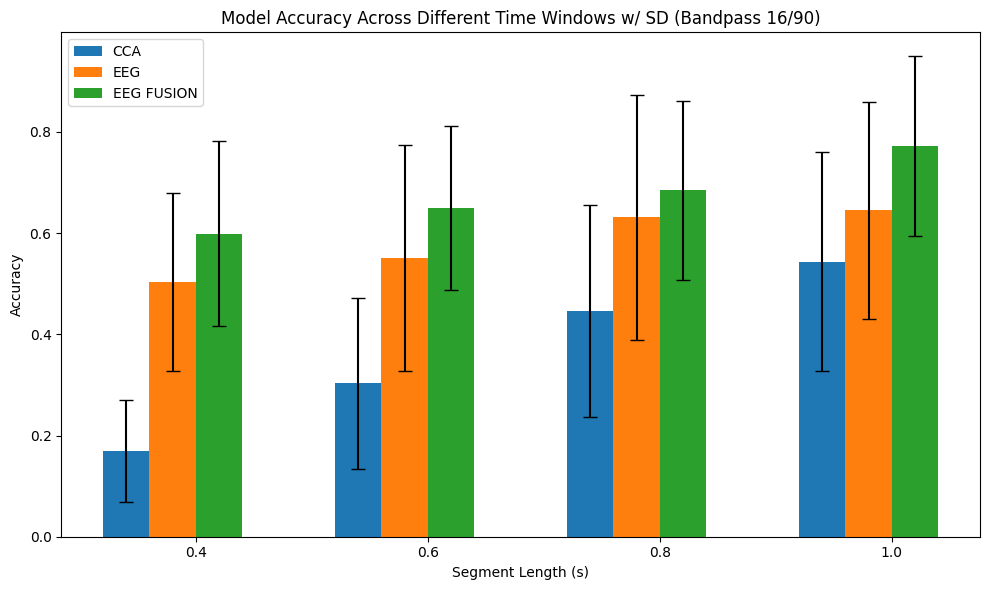

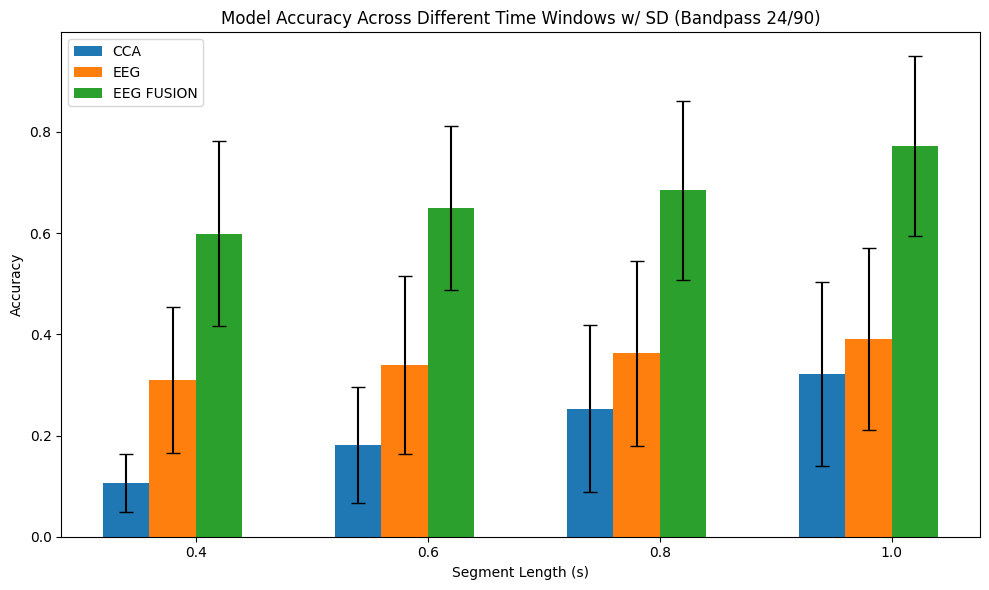

In [5]:
models = ['CCA', 'EEG', 'EEG FUSION']
segment_lengths = [0.4, 0.6,0.8, 1.0]

#Filter band 1 (8,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies1[i*4:(i+1)*4]
    model_std_devs = std_devs1[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, model_accuracies, bar_width, label=model_name,
           yerr=model_std_devs, capsize=5, color='C'+str(i))

ax.set_xlabel('Time window (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Across Different Time Windows w/ SD (Bandpass 8/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()

plt.tight_layout()
plt.show()

#Filter band 2 (16,90) 
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies2[i*4:(i+1)*4]
    model_std_devs = std_devs2[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, model_accuracies, bar_width, label=model_name,
           yerr=model_std_devs, capsize=5, color='C'+str(i))

ax.set_xlabel('Segment Length (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Across Different Time Windows w/ SD (Bandpass 16/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()

plt.tight_layout()
plt.show()


#Filter band 3 (24,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies3[i*4:(i+1)*4]
    model_std_devs = std_devs3[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, model_accuracies, bar_width, label=model_name,
           yerr=model_std_devs, capsize=5, color='C'+str(i))

ax.set_xlabel('Segment Length (s)')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Across Different Time Windows w/ SD (Bandpass 24/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()

plt.tight_layout()
plt.show()

# Segment length vs ITR

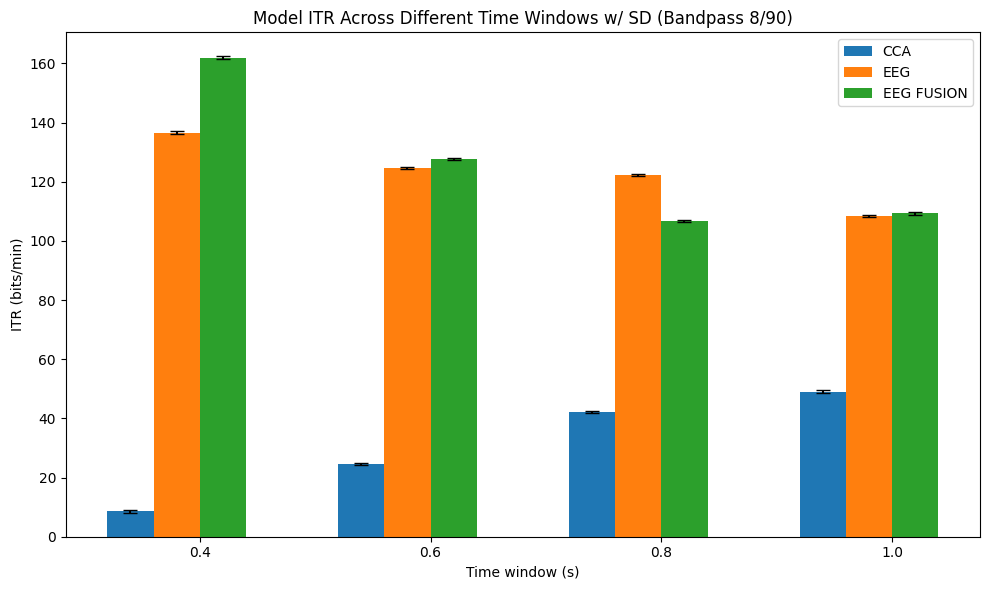

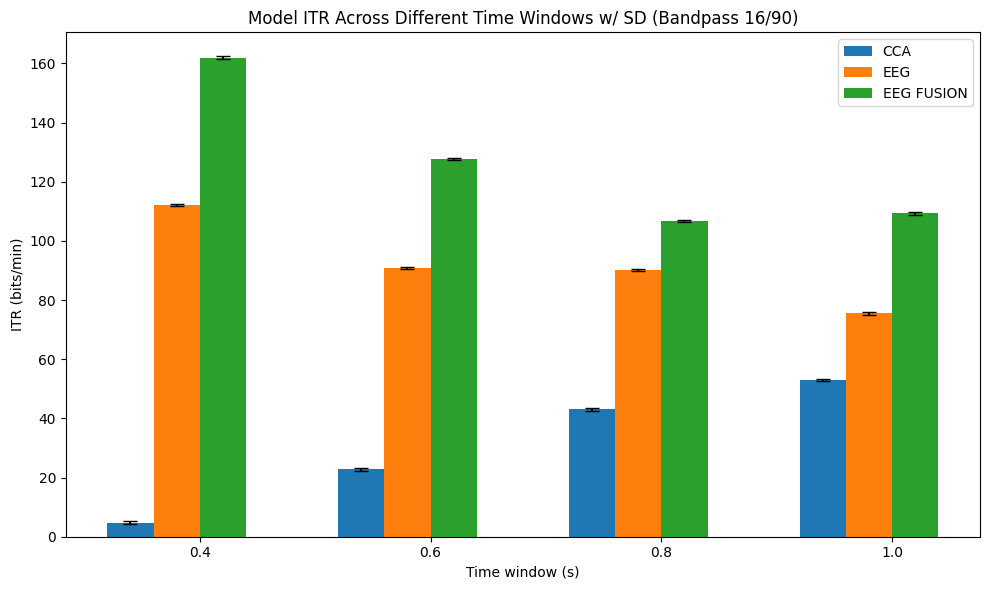

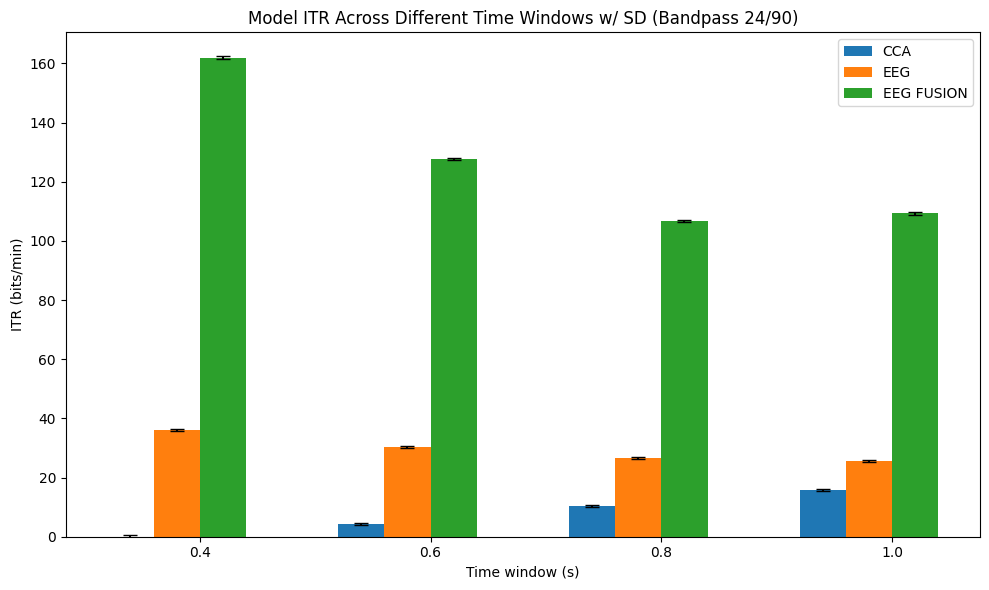

In [6]:
#Filter band 1 (8,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies1[i*4:(i+1)*4]
    model_std_devs = std_devs1[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, itr1[i*4:(i+1)*4], bar_width, label=model_name, capsize=5, color='C'+str(i), yerr=itr_time[i*4])

ax.set_xlabel('Time window (s)')
ax.set_ylabel('ITR (bits/min)')
ax.set_title('Model ITR Across Different Time Windows w/ SD (Bandpass 8/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
plt.ylim(bottom=0)
ax.legend()

plt.tight_layout()
plt.show()

#Filter band 2 (8,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies1[i*4:(i+1)*4]
    model_std_devs = std_devs1[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, itr2[i*4:(i+1)*4], bar_width, label=model_name, capsize=5, color='C'+str(i), yerr=itr_time[i*4])

ax.set_xlabel('Time window (s)')
ax.set_ylabel('ITR (bits/min)')
ax.set_title('Model ITR Across Different Time Windows w/ SD (Bandpass 16/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

#Filter band 3 (24,90)
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
index = np.arange(len(segment_lengths))

for i, model_name in enumerate(models):
    model_accuracies = mean_accuracies1[i*4:(i+1)*4]
    model_std_devs = std_devs1[i*4:(i+1)*4]
    
    ax.bar(index + i * bar_width, itr3[i*4:(i+1)*4], bar_width, label=model_name, capsize=5, color='C'+str(i), yerr=itr_time[i*4])

ax.set_xlabel('Time window (s)')
ax.set_ylabel('ITR (bits/min)')
ax.set_title('Model ITR Across Different Time Windows w/ SD (Bandpass 24/90)')
ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(segment_lengths)
ax.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

# Filter combinations (9 channels)

In [7]:
filter_1 = eeg_8_250
filter_2 = eeg_16_250
filter_3 = eeg_24_250

filter_1_and_2 = extract_accuracies_from_file("results/eeg_fusion_8_16_results_9chans_90_250.json")
filter_1_and_3 = extract_accuracies_from_file("results/eeg_fusion_8_24_results_9chans_90_250.json")
filter_2_and_3 = extract_accuracies_from_file("results/eeg_fusion_16_24_results_9chans_90_250.json")
filter_all = eeg_fusion3_250

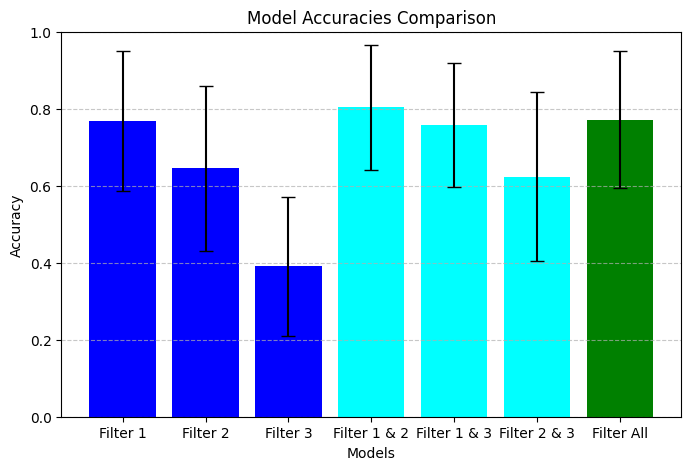

In [8]:
# Example data
models = ['Filter 1', 'Filter 2', 'Filter 3', 'Filter 1 & 2', 'Filter 1 & 3', 'Filter 2 & 3', 'Filter All']
accuracies = [np.mean(filter_1), 
              np.mean(filter_2), 
              np.mean(filter_3), 
              np.mean(filter_1_and_2), 
              np.mean(filter_1_and_3), 
              np.mean(filter_2_and_3),
              np.mean(filter_all)]

std_devs = [np.std(filter_1),
            np.std(filter_2),
            np.std(filter_3),
            np.std(filter_1_and_2),
            np.std(filter_1_and_3),
            np.std(filter_2_and_3),
            np.std(filter_all)]

# Create the plot
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, yerr=std_devs, color=['blue','blue','blue','cyan','cyan','cyan','green'], capsize=5)

# Labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracies Comparison")
plt.ylim(0, 1)  # Set Y-axis limit from 0 to 100
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the graph
plt.show()

# Channel selection

In [9]:
channel_3 = extract_accuracies_from_file("results/eeg_results_3channels_8_90.json")
channel_6 = extract_accuracies_from_file("results/eeg_results_6channels_8_90.json")
channel_9 = extract_accuracies_from_file("results/eeg_results_9chans_8_90_250.json")
channel_64 = extract_accuracies_from_file("results/eeg_results_64channels_8_90.json")

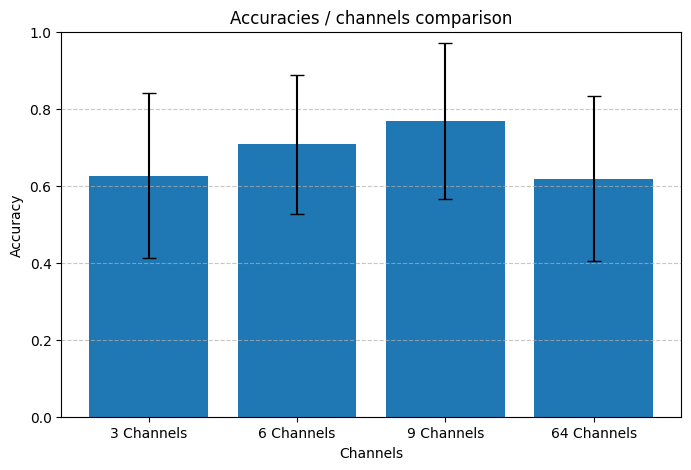

In [10]:
channels = ['3 Channels', '6 Channels', '9 Channels', '64 Channels']#, '9 Channels', '64 Channels']
data = [np.mean(channel_3), np.mean(channel_6), np.mean(channel_9), np.mean(channel_64)]
stds = [np.std(channel_3), np.std(channel_6), np.std(channel_9), np.std(channel_64)]

# Create the plot
plt.figure(figsize=(8, 5))
plt.bar(channels, data,yerr=stds, capsize=5)

# Labels and title
plt.xlabel("Channels")
plt.ylabel("Accuracy")
plt.title("Accuracies / channels comparison")
plt.ylim(0, 1)  # Set Y-axis limit from 0 to 100
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the graph
plt.show()

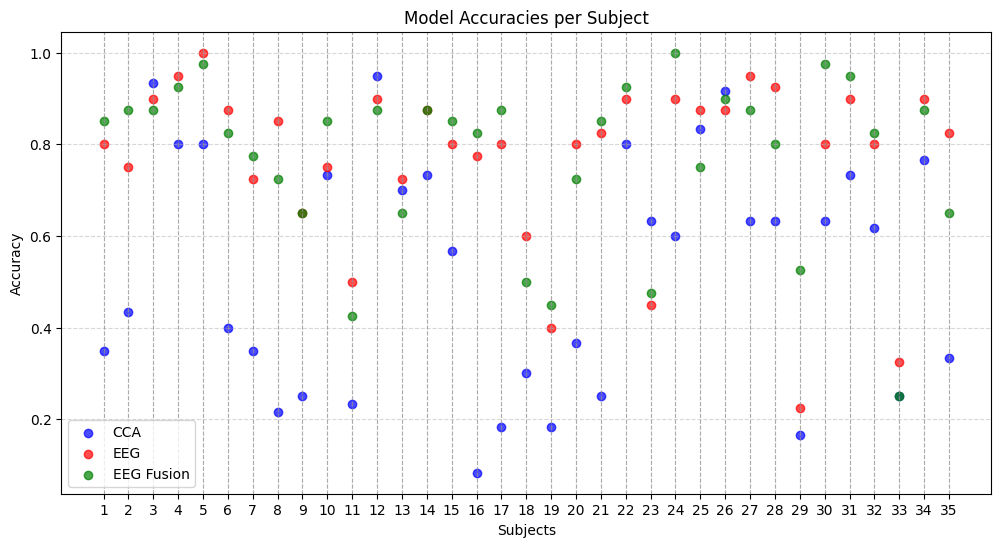

In [11]:
plt.figure(figsize=(12, 6))  # Adjust width and height as needed

subjects = np.arange(1, 36)
a = cca_8_250
b = eeg_8_250
c = eeg_fusion3_250

# Plot each model's accuracy as scatter points
plt.scatter(subjects, a, label="CCA", marker='o', color='b', alpha=0.7)
plt.scatter(subjects, b, label="EEG", marker='o', color='r', alpha=0.7)
plt.scatter(subjects, c, label="EEG Fusion", marker='o', color='g', alpha=0.7)

# Labels and legend
plt.xlabel("Subjects")
plt.ylabel("Accuracy")
plt.title("Model Accuracies per Subject")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(subjects)  # Force X-axis to show every subject

for s in subjects:
    plt.axvline(x=s, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)


# Show the plot
plt.show()

# Visulisation of filters

In [20]:
#eeg_model = tf.keras.models.load_model("model.keras")
channels64 = []

with open("D:/2024/7-9/dissertation/code/64-channels.loc", "r") as file:
    lines = file.read().splitlines()  # Reads without keeping `\n`
    for line in lines:
        chan = line.split()[3]
        channels64.append(chan)

optimal_channels = [45,47,49,52,55,58,60,61,62]
channels9 = [channels64[oc] for oc in optimal_channels]
        
#missing_channels = ["CB1", "CB2", "CPZ"]  # List of missing channels

#valid_indices = [i for i, ch in enumerate(channels64) if ch not in missing_channels]
#print(valid_indices)
#print(channels9)

In [39]:
from mne.channels import make_standard_montage
from mne.viz import plot_topomap
import matplotlib.cm as cm
import tensorflow as tf

def visualise_temp_spat(eeg_model,  cmap = 'Spectral_r', image_name=None, beach_ball=False):
        #CONV2D [1] Temporal?
    #DepthwiseConv2D [3] Spatial?

    #cmap = 'Spectral_r'
    outlines = 'head'
    image_interp = 'cubic'
    if beach_ball:
        outlines = None
        image_interp = 'nearest'
    
    #chans = ['P3', 'Pz', 'P4', 'PO7', 'POz', 'O1', 'Oz', 'O2', 'PO8']
    spatial_filters = np.array(eeg_model.layers[3].weights[0]).squeeze(1) #removes singleton dimension (chans, F1 ,depth filters)
    #print(spatial_filters.shape) # (channels, F1, D)
    n_channels, n_filters, components = spatial_filters.shape
    sfreq = 1.0 # 250 
    info = mne.create_info(ch_names=channels9, sfreq=sfreq, ch_types='eeg')
    #info.set_channel_types({'CB1': 'misc', 'CB2': 'misc', 'CPZ': 'misc'})
    #info.rename_channels({'FP1': 'Fp1', 'FPZ': 'Fpz', 'FP2': 'Fp2', 'FZ': 'Fz',
                           #'PZ': 'Pz'})
    info.rename_channels({'PZ': 'Pz'})
    
    montage = make_standard_montage('standard_1020')
    info.set_montage(montage, on_missing='ignore')
    dummy_evoked = mne.EvokedArray(np.zeros((9, 1)), info)
    dummy_evoked.set_montage(montage)
    
    
    temporal_filters = np.array(eeg_model.layers[1].weights[0]).squeeze() # collapse singleton dimensions
    time_axis = np.linspace(0, 250, 125)  # From 0 to 0.5 seconds, 125 points
    
    # Create subplots
    nrows = 3
    ncols = 8

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(25, 10))
    
    y_min = np.min(temporal_filters) - 0.05  # Minimum y limit for all plots
    y_max = np.max(temporal_filters) + 0.05 # Maximum y limit for all plots
    
    for i in range(n_filters):
        axes[0,i].set_ylim(y_min,y_max)
        axes[0,i].plot(time_axis, temporal_filters[:, i], label=f'Filter {i+1}')
        axes[0,i].set_xticks([0,250])
        axes[0,i].set_title(f"Temp. filter {i+1}")
        if i == 0:
            pass
            #axes[0,i].set_yticks([-0.2,-0.1,0.0,0.1,0.2])
        else:
            axes[0,i].set_yticks([])
        for component in range(2):
            filter_component = spatial_filters[:, i, component]
            im = plot_topomap(filter_component, dummy_evoked.info, show=False, axes=axes[component+1,i], outlines=outlines, cmap=cmap, ch_type='eeg'
                        , contours=0, image_interp=image_interp)
    
    axes[1,0].set_title("Spat. Fil. 1" , rotation=90, ha='center', va='center', x = -0.25, y = 0.5, family='monospace')
    axes[2,0].set_title("Spat. Fil. 2" , rotation=90, ha='center', va='center', x = -0.25, y = 0.5, family='monospace')
    
    norm = plt.Normalize(vmin=np.min(spatial_filters[:, :, :]), vmax=np.max(spatial_filters[:, :, :]))
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Only needed for ScalarMappable
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    #cbar.set_label('Feature Value')

    if not image_name == None:
        fig.savefig(image_name, dpi=300, bbox_inches="tight")  # High-quality save
    #plt.tight_layout()
    plt.show()
        

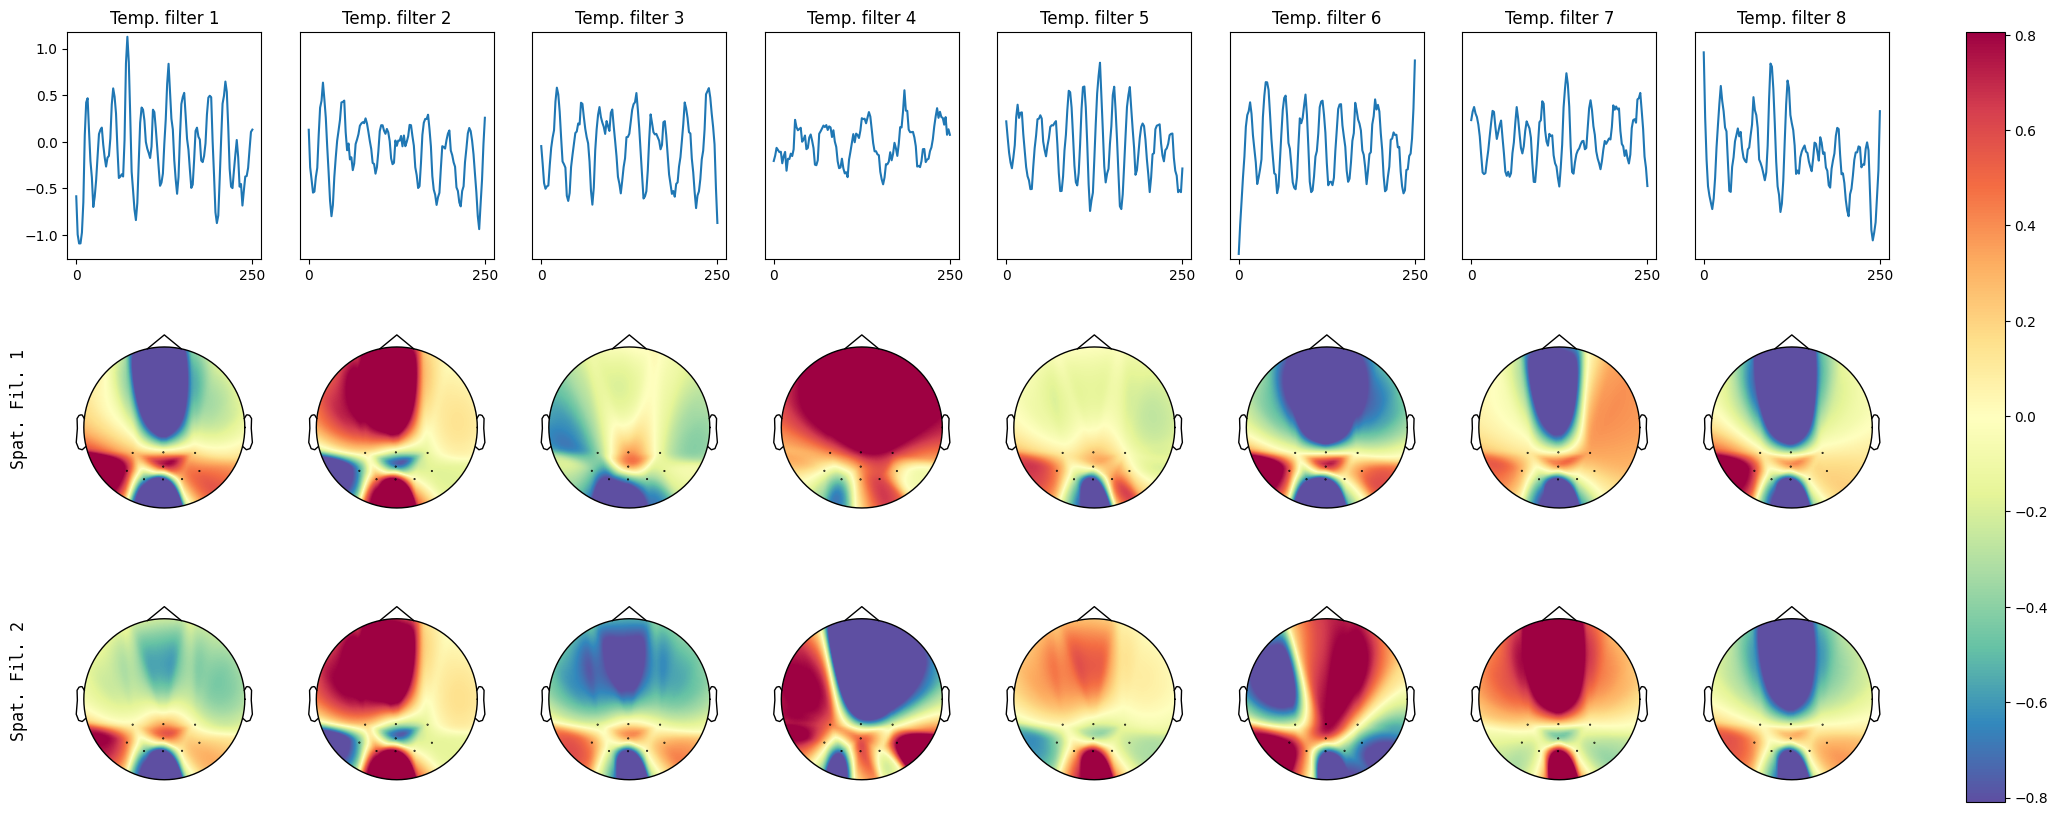

In [40]:
eeg_model = tf.keras.models.load_model("trained_models/model_9chan_sub3.keras")

visualise_temp_spat(eeg_model, image_name = None, beach_ball = False)

In [29]:
from itertools import combinations

def set_temporal_zero(model, i):
    layer = model.layers[1]
    weights = np.array(layer.get_weights())
    weights[:,:,:,:,i] = 0.0
    layer.set_weights(weights)  # Set the weights to zero

def ablation_study(eeg_model, testX, testY, choose=2, show = True):
    orig_w = np.array(eeg_model.layers[1].get_weights()).copy()
    #spatial_filters = np.array(eeg_model.layers[3].weights[0]).squeeze(1) #removes singleton dimension (chans, F1 ,depth filters)
    #temporal_filters = np.array(eeg_model.layers[1].weights[0]).squeeze() # collapse singleton dimensions
    baseline_acc = eeg_model.evaluate(testX,testY, verbose=0)[1]
    print("Base accuracy: ", baseline_acc)
    
    items = list(range(8))  # Example list of indices from 0 to 7
    best = []

    for combo in combinations(range(len(items)), choose):
        eeg_model.layers[1].set_weights(orig_w)
        chosen = np.array([x for x in items if x not in combo])
        for j in chosen:
            set_temporal_zero(eeg_model, j)
        result = eeg_model.evaluate(testX, testY, verbose=False)
        best.append([result[1], combo])
    best = sorted(best, key = lambda x:x[0], reverse=True) 
    top = best[0]
    print(f"Top {choose} filter accuracy: {top[0]}")
    
    fig, axes = show and plt.subplots(nrows=1, ncols=choose, figsize=(15, 4)) or (None,None)
    eeg_model.layers[1].set_weights(orig_w)
    if show:
        axes = axes.flatten()
    temporal_filters = np.array(eeg_model.layers[1].weights[0]).squeeze() # collapse singleton dimensions
    time_axis = np.linspace(0, 250, 125)  # From 0 to 0.5 seconds, 125 points
    p = 0
    rv = []
    for i in top[1]:
        rv.append(temporal_filters[:,i])
        if (show):
            axes[p].plot(time_axis, temporal_filters[:, i], label=f'Filter {i+1}')
            p = p + 1
    if (show):
        fig.tight_layout()
    #ig.
        plt.show()
    print("Top filters :", top[1])
    return rv

testX5 = np.fromfile("subject_segments/sub5.dat", dtype='float').reshape(240,9,250)
testY5 = np.fromfile("subject_segments/sub5_y.dat", dtype='float').reshape(240,10)

testX3 = np.fromfile("subject_segments/sub3.dat", dtype='float').reshape(240,9,250)
testY3 = np.fromfile("subject_segments/sub3_y.dat", dtype='float').reshape(240,10)

testX20 = np.fromfile("subject_segments/sub20.dat", dtype='float').reshape(240,9,250)
testY20 = np.fromfile("subject_segments/sub20_y.dat", dtype='float').reshape(240,10)

In [30]:
def show_temporal_wavelet(temporal_filter, title = "Insert Title"):
    fs = 250  # Sampling frequency in Hz

    # Define wavelet scales corresponding to frequencies
    frequencies = np.linspace(0, 90, 50)  # 5-100 Hz range
    scales = fs / (2 * frequencies)  # Convert frequencies to wavelet scales
    
    # Perform Continuous Wavelet Transform (CWT) using Morlet wavelet
    cwt_matrix = scipy.signal.cwt(temporal_filter, scipy.signal.morlet2, scales, w=6)
    
    # Plot wavelet power spectrum
    plt.figure(figsize=(8,6))
    plt.imshow(np.abs(cwt_matrix), aspect='auto', extent=[0, len(temporal_filter), frequencies[-1], frequencies[0]], cmap='jet')
    plt.colorbar(label='Magnitude')
    plt.xlabel('Time (samples)')
    plt.ylabel('Frequency (Hz)')
    plt.title(title)
    plt.show()

def show_temporal_frequency_transform(temporal_filter, title = 'Insert title'):
    fs = 250  # Sampling frequency (Hz), adjust based on your EEG data
    freqs = np.fft.rfftfreq(len(temporal_filter), 1/fs)  # Frequency axis
    fft_vals = np.abs(np.fft.rfft(temporal_filter))  # Compute FFT magnitude
    
    # Plot frequency response
    plt.figure(figsize=(8,4))
    plt.plot(freqs, fft_vals)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.title(title)
    plt.xlim([0, 100])  # Focus on 0-100 Hz range
    plt.grid()
    plt.show()

def show_temporal_frequency_transform_mean(temporal_filters, title="Insert name"):
    all_fft_vals = []
    for temporal_filter in temporal_filters:
        fs = 250  # Sampling frequency (Hz), adjust based on your EEG data
        freqs = np.fft.rfftfreq(len(temporal_filter), 1/fs)  # Frequency axis
        fft_vals = np.abs(np.fft.rfft(temporal_filter))  # Compute FFT magnitude
        all_fft_vals.append(fft_vals)
    
    
    
    avg_fft = np.mean(all_fft_vals, axis=0)  # all_fft_vals = list of FFTs from all subjects
    plt.plot(freqs, avg_fft)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Average Magnitude')
    plt.title(title)
    plt.xlim([0, 100])
    plt.show()

def get_temporal_filters(model):
    temporal_filters = np.array(model.layers[1].weights[0]).squeeze() # collapse singleton dimensions
    return temporal_filters

Base accuracy:  0.9833333492279053
Top 2 filter accuracy: 0.30416667461395264


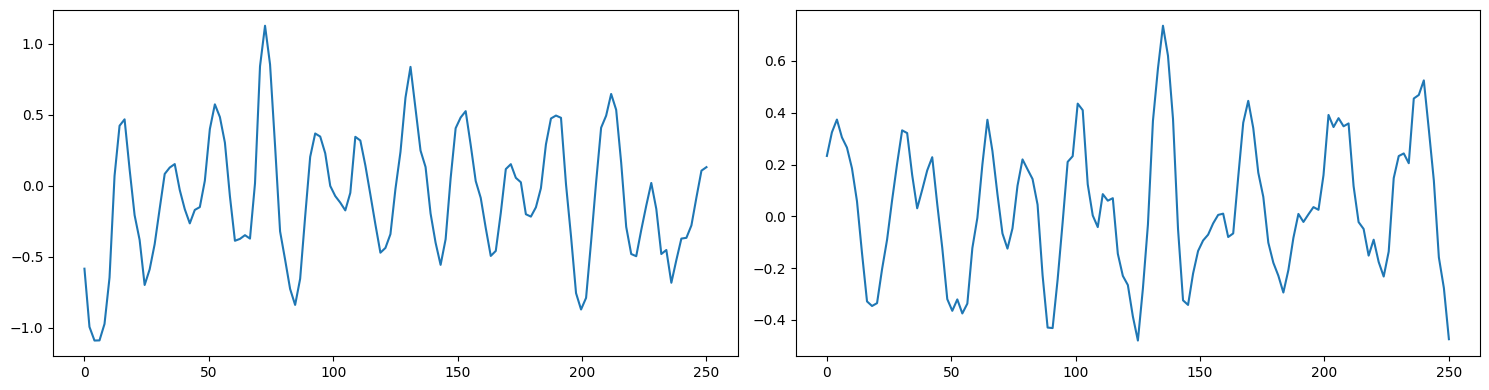

Top filters : (0, 6)


C:\Users\qianqian\AppData\Local\Temp\ipykernel_4648\2487509018.py:6: RuntimeWarning: divide by zero encountered in divide
  scales = fs / (2 * frequencies)  # Convert frequencies to wavelet scales
C:\Users\qianqian\AppData\Local\Temp\ipykernel_4648\2487509018.py:9: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  cwt_matrix = scipy.signal.cwt(temporal_filter, scipy.signal.morlet2, scales, w=6)


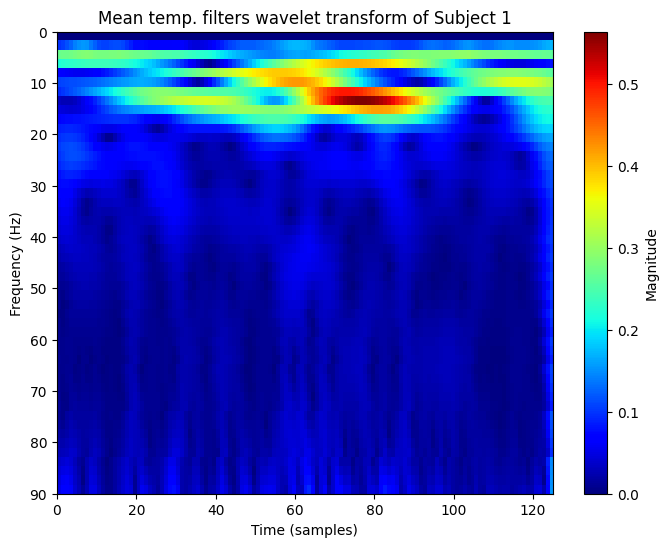

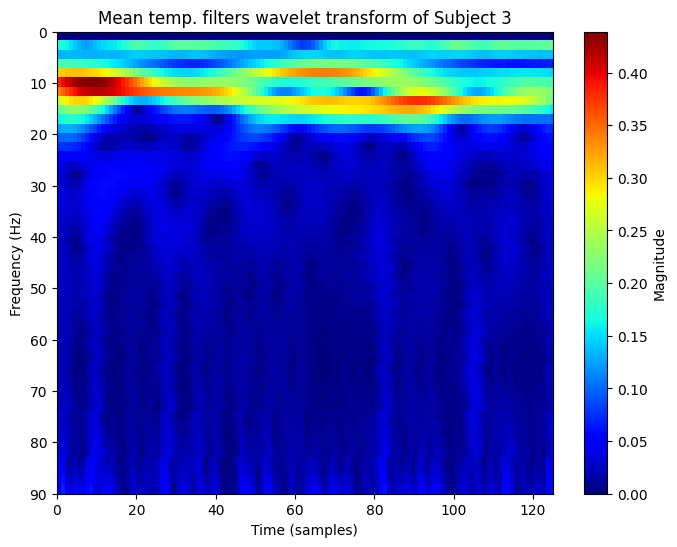

In [31]:
model_s5 = tf.keras.models.load_model("trained_models/model_9chan_sub5.keras")
model_s3 = tf.keras.models.load_model("trained_models/model_9chan_sub3.keras")
model_s1 = tf.keras.models.load_model("trained_models/model_9chan_sub1.keras")

#top_filters5 = ablation_study(model_s5, testX5, testY5, 4, show = True) # Show = false to hide graph
#top_filters3 = ablation_study(model_s3, testX3, testY3, 4, show = True)
ablation_study(model_s3, testX3, testY3, 2)

show_temporal_wavelet(np.mean(get_temporal_filters(model_s1),axis=1), title = "Mean temp. filters wavelet transform of Subject 1")
show_temporal_wavelet(np.mean(get_temporal_filters(model_s3),axis=1), title = "Mean temp. filters wavelet transform of Subject 3")
#show_temporal_frequency_transform_mean(top_filters5, title="Subject 5")